# Отчёт по лабораторной работе 4

Плотников Юрий Группа 8Е21

### 1. Цель работы
Решение задачи детектирования лиц и классификации по полу (мужчина/женщина) с использованием HOG+SVM для детекции и CNN для классификации.

### Подключим библиотеки

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import copy
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from skimage.feature import hog

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("PyTorch version:", torch.__version__)

OpenCV version: 4.13.0
NumPy version: 1.23.5
PyTorch version: 2.11.0+cu126


Проверяем подключение к GPU

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Используемое устройство:", device)
if device.type == 'cuda':
    print("GPU:", torch.cuda.get_device_name(0))
    print("Память GPU:", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

Используемое устройство: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Память GPU: 6.441926656 GB


### Загрузка датасета UTKFace
Используем датасет UTKFace, содержащий лица с метками пола (0 – мужчина, 1 – женщина). Загружаем изображения и показываем как оригинальные цветные примеры, так и преобразованные (grayscale 64x64), используемые для обучения.

In [3]:
DATA_PATH = 'UTKFace/UTKFace/'  # путь к папке с изображениями

In [4]:
def load_utkface_data(data_path='UTKFace', img_size=64):
    """Загрузка UTKFace датасета в grayscale и заданного размера."""
    images = []
    labels = []
    all_files = [f for f in os.listdir(data_path) if f.endswith('.jpg') or f.endswith('.chip.jpg')]
    for filename in tqdm(all_files, desc='Загрузка'):
        try:
            clean_name = filename.replace('.chip', '')
            parts = clean_name.split('_')
            if len(parts) >= 2:
                gender = int(parts[1])
                img_path = os.path.join(data_path, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    resized = cv2.resize(gray, (img_size, img_size))
                    normalized = resized / 255.0
                    images.append(normalized)
                    labels.append(gender)
        except:
            continue
    return np.array(images), np.array(labels)

def load_original_images(data_path='UTKFace', num=9):
    """Загрузка нескольких оригинальных цветных изображений для визуализации."""
    all_files = [f for f in os.listdir(data_path) if f.endswith('.jpg') or f.endswith('.chip.jpg')]
    male_files = []
    female_files = []
    for f in all_files:
        clean = f.replace('.chip', '')
        parts = clean.split('_')
        if len(parts) >= 2:
            try:
                g = int(parts[1])
                if g == 0: male_files.append(f)
                else: female_files.append(f)
            except: pass
    male_samples = np.random.choice(male_files, min(num, len(male_files)), replace=False)
    female_samples = np.random.choice(female_files, min(num, len(female_files)), replace=False)
    return male_samples, female_samples

# Загружаем данные
X, y = load_utkface_data(DATA_PATH)
print(f"Загружено изображений: {len(X)}")
print(f"Мужчины: {np.sum(y == 0)}, Женщины: {np.sum(y == 1)}")
print(f"Форма данных: {X.shape}")

Загрузка: 100%|██████████| 23708/23708 [00:07<00:00, 3071.57it/s]


Загружено изображений: 23708
Мужчины: 12391, Женщины: 11317
Форма данных: (23708, 64, 64)


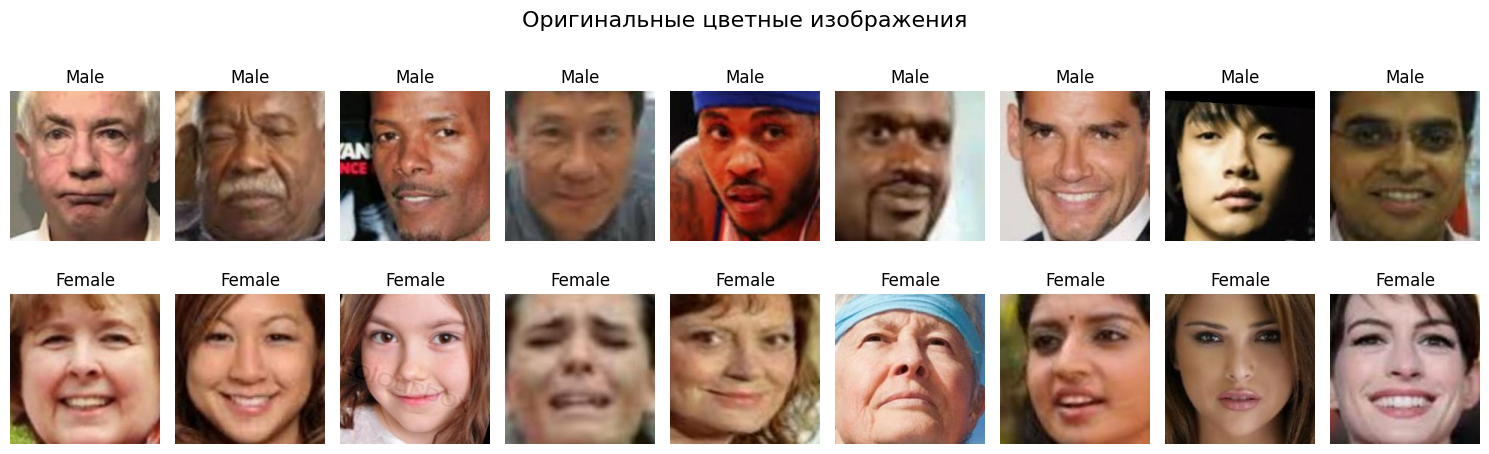

In [5]:
# Отображение примеров оригинальных цветных изображений
male_samples, female_samples = load_original_images(DATA_PATH)
fig, axes = plt.subplots(2, 9, figsize=(15, 5))
for i, f in enumerate(male_samples):
    img = cv2.cvtColor(cv2.imread(os.path.join(DATA_PATH, f)), cv2.COLOR_BGR2RGB)
    axes[0,i].imshow(img)
    axes[0,i].set_title('Male')
    axes[0,i].axis('off')
for i, f in enumerate(female_samples):
    img = cv2.cvtColor(cv2.imread(os.path.join(DATA_PATH, f)), cv2.COLOR_BGR2RGB)
    axes[1,i].imshow(img)
    axes[1,i].set_title('Female')
    axes[1,i].axis('off')
plt.suptitle('Оригинальные цветные изображения', fontsize=16)
plt.tight_layout()
plt.show()

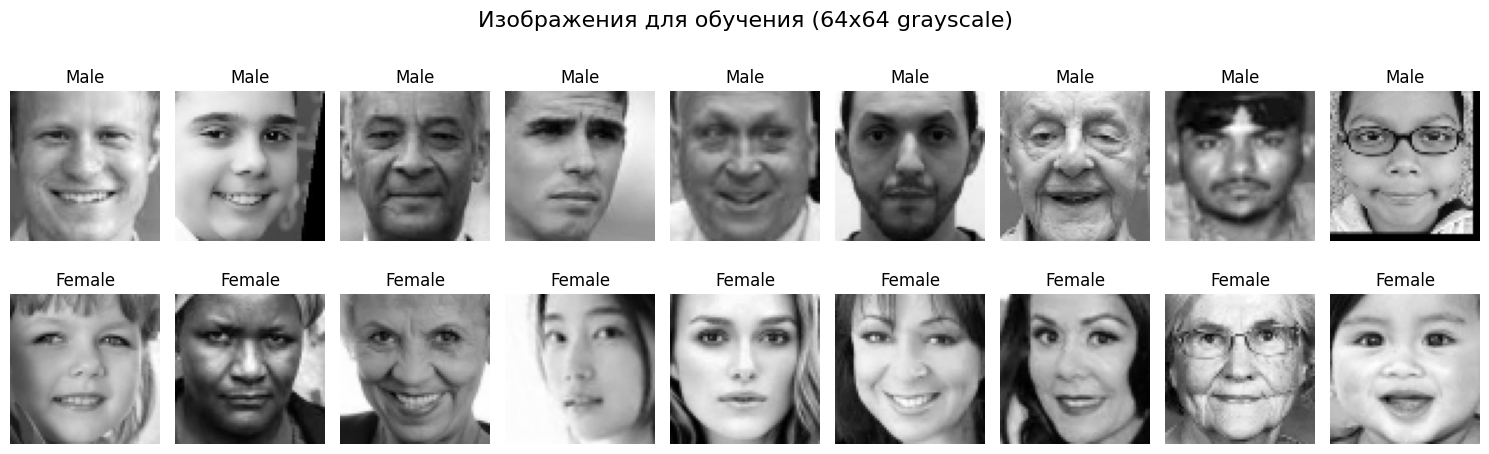

In [6]:
# Отображение примеров после предобработки (grayscale 64x64)
fig, axes = plt.subplots(2, 9, figsize=(15, 5))
male_idx = np.random.choice(np.where(y == 0)[0], 9, replace=False)
female_idx = np.random.choice(np.where(y == 1)[0], 9, replace=False)
for i in range(9):
    axes[0,i].imshow(X[male_idx[i]], cmap='gray')
    axes[0,i].set_title('Male')
    axes[0,i].axis('off')
    axes[1,i].imshow(X[female_idx[i]], cmap='gray')
    axes[1,i].set_title('Female')
    axes[1,i].axis('off')
plt.suptitle('Изображения для обучения (64x64 grayscale)', fontsize=16)
plt.tight_layout()
plt.show()

### Разделение данных

In [7]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42, stratify=y_temp)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (17128, 64, 64), Val: (3023, 64, 64), Test: (3557, 64, 64)


### 2. Детекция лиц: HOG+SVM
Обучаем линейный SVM на HOG-признаках для обнаружения лиц. Позитивные примеры – реальные лица из UTKFace, негативные – случайные патчи и шум.

In [8]:
def train_hog_svm():
    # Позитивные примеры (лица)
    pos_samples = []
    for i in range(2000):
        img = (X[i] * 255).astype(np.uint8)
        feat = hog(img, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2))
        pos_samples.append(feat)
    # Негативные примеры
    neg_samples = []
    for i in range(2000):
        img = (X[np.random.randint(0, len(X))] * 255).astype(np.uint8)
        h, w = img.shape
        crop_size = np.random.randint(20, 50)
        x = np.random.randint(0, w - crop_size)
        y = np.random.randint(0, h - crop_size)
        patch = img[y:y+crop_size, x:x+crop_size]
        patch = cv2.resize(patch, (64,64))
        feat = hog(patch, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2))
        neg_samples.append(feat)
    for _ in range(500):
        patch = np.random.randint(0, 256, (64,64), dtype=np.uint8)
        feat = hog(patch, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2))
        neg_samples.append(feat)
    X_hog = np.vstack([pos_samples, neg_samples])
    y_hog = np.hstack([np.ones(len(pos_samples)), np.zeros(len(neg_samples))])
    X_tr, X_te, y_tr, y_te = train_test_split(X_hog, y_hog, test_size=0.2, random_state=42, stratify=y_hog)
    svm = SVC(kernel='rbf', C=10.0, gamma='scale', probability=True, random_state=42)
    svm.fit(X_tr, y_tr)
    y_pred = svm.predict(X_te)
    print("Точность HOG+SVM:", accuracy_score(y_te, y_pred))
    print(classification_report(y_te, y_pred, target_names=['Не лицо', 'Лицо']))
    return svm

svm = train_hog_svm()

Точность HOG+SVM: 0.9966666666666667
              precision    recall  f1-score   support

     Не лицо       1.00      1.00      1.00       500
        Лицо       1.00      0.99      1.00       400

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



### 3. Классификация пола: CNN (GenderCNN)
Архитектура: 3 блока Conv2D+BatchNorm+ReLU+MaxPool+Dropout, затем полносвязные слои.

In [9]:
class GenderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*8*8, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 1), nn.Sigmoid()
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [10]:
# Подготовка данных для CNN
X_tensor = torch.tensor(X_train.reshape(-1,1,64,64), dtype=torch.float32)
y_tensor_cnn = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val.reshape(-1,1,64,64), dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test.reshape(-1,1,64,64), dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_tensor, y_tensor_cnn)
val_ds = TensorDataset(X_val_t, y_val_t)
test_ds = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

model = GenderCNN().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [11]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

In [12]:
epochs = 20
train_losses, train_accs = [], []
val_losses, val_accs = [], []
best_val_acc = 0.0
best_wts = None
for epoch in range(epochs):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    scheduler.step(val_loss)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_wts = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch+1}/{epochs}: Train Acc {tr_acc:.4f}, Val Acc {val_acc:.4f}")
    # Early stopping
    if epoch > 10 and val_acc < max(val_accs[-5:]):
        print("Early stopping")
        break
model.load_state_dict(best_wts)
print("Best val acc:", best_val_acc)

Epoch 1/20: Train Acc 0.6590, Val Acc 0.7704
Epoch 2/20: Train Acc 0.8178, Val Acc 0.8521
Epoch 3/20: Train Acc 0.8549, Val Acc 0.8591
Epoch 4/20: Train Acc 0.8661, Val Acc 0.8726
Epoch 5/20: Train Acc 0.8793, Val Acc 0.8793
Epoch 6/20: Train Acc 0.8854, Val Acc 0.8925
Epoch 7/20: Train Acc 0.8894, Val Acc 0.8836
Epoch 8/20: Train Acc 0.9009, Val Acc 0.8898
Epoch 9/20: Train Acc 0.9025, Val Acc 0.8769
Epoch 10/20: Train Acc 0.9097, Val Acc 0.8895
Epoch 11/20: Train Acc 0.9094, Val Acc 0.8915
Epoch 12/20: Train Acc 0.9139, Val Acc 0.8971
Epoch 13/20: Train Acc 0.9166, Val Acc 0.8951
Early stopping
Best val acc: 0.8971220641746609


In [13]:
# Оценка на тесте
test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8971


### 4. Финальный пайплайн: детекция (HOG+SVM) + классификация пола (CNN)

In [14]:
# Функция детекции лиц с помощью обученного SVM (пирамида, скользящее окно, NMS)
def sliding_window(image, window_size, step_size):
    for y in range(0, image.shape[0] - window_size[1] + 1, step_size):
        for x in range(0, image.shape[1] - window_size[0] + 1, step_size):
            yield (x, y, image[y:y+window_size[1], x:x+window_size[0]])

def pyramid(image, scale=1.5, min_size=(64,64)):
    yield image
    while True:
        w = int(image.shape[1] / scale)
        h = int(image.shape[0] / scale)
        if w < min_size[0] or h < min_size[1]:
            break
        image = cv2.resize(image, (w, h))
        yield image

def non_max_suppression(boxes, overlapThresh=0.3):
    if len(boxes) == 0: return []
    if boxes.dtype.kind == "i":
        boxes = boxes.astype("float")
    pick = []
    x1 = boxes[:,0]; y1 = boxes[:,1]; x2 = boxes[:,2]; y2 = boxes[:,3]
    area = (x2 - x1 + 1) * (y2 - y1 + 1)
    idxs = np.argsort(y2)
    while len(idxs) > 0:
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)
        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.minimum(x2[i], x2[idxs[:last]])
        yy2 = np.minimum(y2[i], y2[idxs[:last]])
        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)
        overlap = (w * h) / area[idxs[:last]]
        idxs = np.delete(idxs, np.concatenate(([last], np.where(overlap > overlapThresh)[0])))
    return boxes[pick].astype("int")

def detect_faces_svm(image_gray, svm, window_size=(64,64), step=8, scale=1.2, conf_thresh=0.5):
    boxes = []
    for resized in pyramid(image_gray, scale=scale, min_size=window_size):
        scale_factor = image_gray.shape[0] / resized.shape[0]
        for (x, y, window) in sliding_window(resized, window_size, step_size=step):
            if window.shape[0] != window_size[1] or window.shape[1] != window_size[0]:
                continue
            hog_feat = hog(window, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2))
            prob = svm.predict_proba([hog_feat])[0][1]
            if prob >= conf_thresh:
                x1 = int(x * scale_factor)
                y1 = int(y * scale_factor)
                x2 = int((x + window_size[0]) * scale_factor)
                y2 = int((y + window_size[1]) * scale_factor)
                boxes.append([x1, y1, x2, y2, prob])
    if boxes:
        boxes = np.array(boxes)
        kept = non_max_suppression(boxes[:, :4].astype(int))
        # вернем рамки с confidence
        result = []
        for k in kept:
            idx = np.where((boxes[:,:4] == k).all(axis=1))[0]
            if len(idx)>0:
                result.append((k[0],k[1],k[2],k[3], boxes[idx[0],4]))
        return result
    return []

In [15]:
# Функция классификации пола вырезанного лица
def classify_gender(face_img, model, device):
    if len(face_img.shape) == 3:
        face_img = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    face_resized = cv2.resize(face_img, (64,64))
    face_norm = face_resized / 255.0
    tensor = torch.tensor(face_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        prob = model(tensor).item()
    label = "Female" if prob > 0.5 else "Male"
    return label, prob

In [16]:
# Пайплайн для папки с изображениями
def process_folder(folder_path, svm, cnn_model, device):
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for fname in image_files:
        img_path = os.path.join(folder_path, fname)
        image = cv2.imread(img_path)
        if image is None: continue
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        faces = detect_faces_svm(gray, svm)
        for (x1,y1,x2,y2,conf) in faces:
            face_img = image[y1:y2, x1:x2]
            label, prob = classify_gender(face_img, cnn_model, device)
            color = (0,255,0) if label == 'Male' else (0,0,255)
            cv2.rectangle(image, (x1,y1), (x2,y2), color, 2)
            cv2.putText(image, f"{label} ({prob:.2f})", (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        plt.figure(figsize=(8,6))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(fname)
        plt.axis('off')
        plt.show()

# Укажите путь к папке с тестовыми изображениями
test_folder = 'test_images'   # замените на свой путь
if os.path.exists(test_folder):
    process_folder(test_folder, svm, model, device)
else:
    print(f"Папка {test_folder} не найдена. Укажите путь к существующей папке.")

Папка test_images не найдена. Укажите путь к существующей папке.
